# 03 · EDA & SQL — which tenders get only one bid?
## Step 1 · Load the clean table

In [151]:
import pandas as pd
import matplotlib.pyplot as plt

In [152]:
# sys lets Python know where to look for files
import sys

# Also look one folder up (the TenderLens folder), where tenderlens_style.py lives
sys.path.append("..")

# Bring in my colours and chart helpers with the short name ts
import tenderlens_style as ts

In [153]:
# Show everything inside my style file (skip hidden names that start with _)
[x for x in dir(ts) if not x.startswith("_")]

['AMBER_BRAND',
 'APP_BG',
 'APP_CARD',
 'APP_SIDEBAR',
 'AXIS',
 'BLUES',
 'FONT',
 'GRID',
 'HILITE',
 'INK',
 'INK2',
 'MULTI',
 'NAVY',
 'NEUTRAL',
 'SINGLE',
 'SURFACE',
 'THIRD',
 'mpl',
 'plt',
 'save_fig',
 'source',
 'title',
 'use_style']

In [154]:
# inspect lets us peek at what each helper needs
import inspect

# Print what goes inside the brackets of each helper
print(inspect.signature(ts.use_style))
print(inspect.signature(ts.title))
print(inspect.signature(ts.source))
print(inspect.signature(ts.save_fig))

()
(ax, finding, subtitle=None)
(fig, text='Source: Assam e-tenders via CivicDataLab')
(fig, path)


In [155]:
# Switch on my TenderLens chart look (colours, fonts, background)
ts.use_style()

In [156]:
# The three columns that hold dates
dates = ["published_date", "last_date", "bid_opening_date"]

# Open the clean table from S2 and read those three columns as real dates
df = pd.read_csv("../data/interim/tenders_clean.csv", parse_dates=dates)

In [157]:
# How big is the table? (rows, columns)
df.shape

(39411, 39)

In [158]:
# Check the date columns are real dates (should say datetime64)
df[dates].dtypes

published_date      datetime64[us]
last_date           datetime64[us]
bid_opening_date    datetime64[us]
dtype: object

## Step 2 · Overall single-bid rate

In [159]:
# Count 1s, 0s and empty values in single_bid (dropna=False also counts the empties)
df["single_bid"].value_counts(dropna=False)

single_bid
NaN    32621
0.0     4746
1.0     2044
Name: count, dtype: int64

In [160]:
# Keep only tenders where we know the answer (single_bid is not empty)
lab = df[df["single_bid"].notna()]

# How many labelled tenders?
lab.shape

(6790, 39)

In [161]:
# Average of 1s and 0s = share of single-bid tenders
lab["single_bid"].mean()

0.30103092783505153

### Insight · Overall single-bid rate
- 6,790 tenders have a known bid count. The other 32,621 are older files with no bidder list, so I left them out instead of guessing.
- 2,044 of the 6,790 got only one bid. That is 30.1%, about 3 in every 10.
- One bid means no competition, so the government has no other price to compare with.
- I use 30.1% as the normal level. Groups well above it are a warning sign, groups well below it are safer.

## Step 3 · Single-bid rate by year

In [162]:
# Take out just the year from each publish date (e.g. 2022-12-05 → 2022)
year = lab["published_date"].dt.year

In [163]:
# How many labelled tenders in each year?
lab.groupby(year)["single_bid"].count()

published_date
2019      20
2020      24
2021     302
2022    4909
2023    1535
Name: single_bid, dtype: int64

In [164]:
# Single-bid rate for each year (average of 1s and 0s in each pile)
rate_by_year = lab.groupby(year)["single_bid"].mean()
rate_by_year

published_date
2019    0.600000
2020    0.416667
2021    0.413907
2022    0.316154
2023    0.224756
Name: single_bid, dtype: float64

In [165]:
# Turn rates into percentages (0.316 → 31.6) so the chart is easy to read
pct = rate_by_year * 100
pct

published_date
2019    60.000000
2020    41.666667
2021    41.390728
2022    31.615400
2023    22.475570
Name: single_bid, dtype: float64

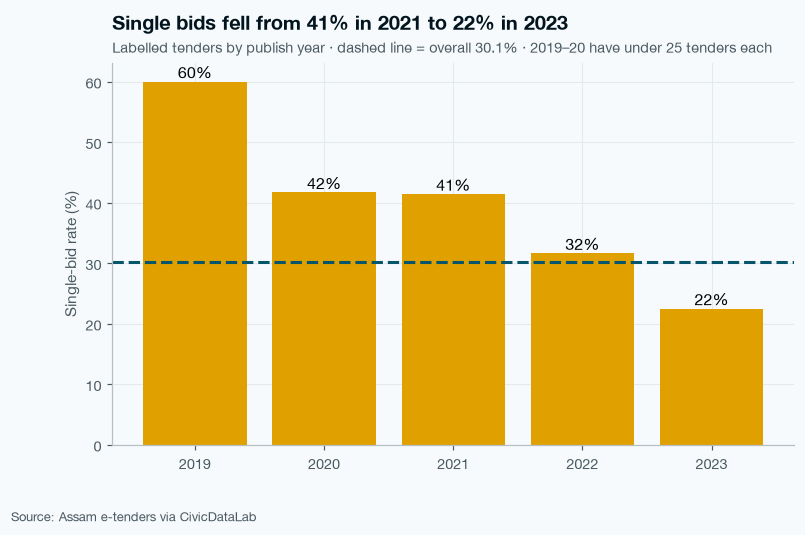

In [166]:
# Make an empty picture: fig = the whole page, ax = the drawing area
fig, ax = plt.subplots(figsize=(8, 4.5))

# One amber bar per year (amber = single-bid colour)
bars = ax.bar(pct.index.astype(str), pct, color=ts.SINGLE)

# Write the % on top of each bar
ax.bar_label(bars, fmt="%.0f%%")

# Dashed line at the overall rate (30.1%) so we can compare each year to it
ax.axhline(30.1, color=ts.THIRD, linestyle="--")

# Name the left axis
ax.set_ylabel("Single-bid rate (%)")

# Title that states the finding + a small subtitle
ts.title(ax, "Single bids fell from 41% in 2021 to 22% in 2023",
         "Labelled tenders by publish year · dashed line = overall 30.1% · 2019–20 have under 25 tenders each")

# Add the source line at the bottom
ts.source(fig)

# Save the chart into reports/figures
ts.save_fig(fig, "../reports/figures/S3a_single_bid_by_year.png")

### Insight · Single-bid rate by year
- The single-bid rate went down over time: 41% in 2021, 32% in 2022 and 22% in January to May 2023.
- 2019 (60%) and 2020 (42%) have only about 20 tenders each, so I did not rely on them.
- Most labelled tenders (95%) are from 2022 and 2023, so those years give the clearest picture.
- Part of the fall may come from which tenders were recorded, not only from more companies bidding.
- The model will learn from older years where single bids were more common and be tested on 2023, so it may predict too many single bids. I need to check this when testing (S5).

## Step 4 · Single-bid rate by department

In [167]:
# For each department: count of labelled tenders AND single-bid rate, side by side
dept = lab.groupby("dept_main")["single_bid"].agg(["count", "mean"])
dept.shape

(83, 2)

In [168]:
# Keep only departments with at least 50 labelled tenders (small piles are too shaky)
dept = dept[dept["count"] >= 50]

In [169]:
# Sort from highest single-bid rate to lowest
dept = dept.sort_values("mean", ascending=False)
dept

,count,mean
dept_main,,
Food Civil Supplies and Consumer Affairs Department,129,0.511628
Public Works Roads Department-Externally Aided Project,176,0.409091
Department of Housing and Urban Affairs,90,0.388889
Irrigation Department,115,0.382609
Directorate of Agriculture and Assam Seed Corporation,206,0.378641
Bodoland Territorial Council,799,0.370463
Principal Secretary- P and RD- Assam Secretariat,69,0.362319
Welfare of Plain Tribes and Backward Classes,179,0.346369
Public Works Building and NH Department,876,0.326484


In [170]:
# Turn the rate into a percentage (0.51 → 51) in a new column
dept["pct"] = dept["mean"] * 100

In [171]:
# Sort smallest → largest, because a sideways chart draws the first row at the bottom
plot_df = dept.sort_values("pct")

In [172]:
# Pick a colour for each department: amber if above the overall 30.1%, grey if below
colors = [ts.SINGLE if p > 30.1 else ts.NEUTRAL for p in plot_df["pct"]]

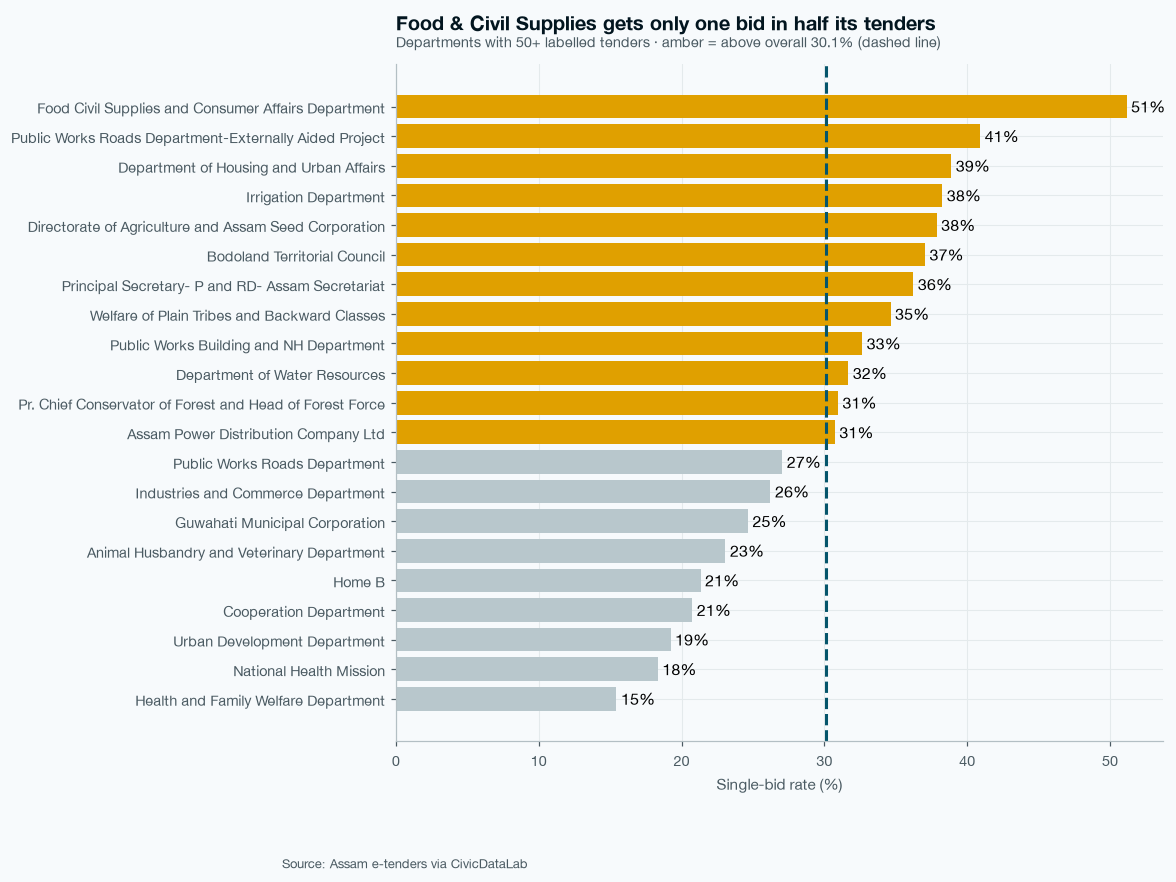

In [173]:
# Empty picture, taller this time because we have 21 departments
fig, ax = plt.subplots(figsize=(9, 8))

# Sideways bars (barh = bar horizontal), one per department
bars = ax.barh(plot_df.index, plot_df["pct"], color=colors)

# Write the % at the end of each bar (padding = small gap)
ax.bar_label(bars, fmt="%.0f%%", padding=3)

# Upright dashed line at the overall rate 30.1%
ax.axvline(30.1, color=ts.THIRD, linestyle="--")

# Name the bottom axis
ax.set_xlabel("Single-bid rate (%)")

# Title that states the finding + subtitle
ts.title(ax, "Food & Civil Supplies gets only one bid in half its tenders",
         "Departments with 50+ labelled tenders · amber = above overall 30.1% (dashed line)")

# Source line and save
ts.source(fig)
ts.save_fig(fig, "../reports/figures/S3b_single_bid_by_department.png")

### Insight · Single-bid rate by department
- Only 21 of 83 departments have 50 or more labelled tenders, so I compared only those.
- Food & Civil Supplies had the highest rate at 51%, about 1 in 2 tenders. PWD Roads (externally aided) was next at 41%.
- The two health departments had the lowest: National Health Mission 18% and Health & Family Welfare 15%. They mostly buy medicines and equipment, which many suppliers can provide.
- 12 of the 21 departments are above 30%.
- Department will be a strong input for the model. Part of the gap may come from what each department buys and when it posted, not only the department itself.

## Step 5 · Single-bid rate by bidding window

In [174]:
# Quick summary of the bidding window (in days) for labelled tenders
lab["bid_window_days"].describe()

count    6786.000000
mean       18.529915
std        11.729690
min         2.000000
25%        12.000000
50%        18.000000
75%        21.000000
max       334.000000
Name: bid_window_days, dtype: float64

In [175]:
# Edges of our bands (-1 so that a 0-day window is included in the first band)
edges = [-1, 7, 14, 21, 30, 1000]

# A name for each band (5 bands, so 5 names)
names = ["0–7 days", "8–14", "15–21", "22–30", "30+"]

In [176]:
# Put each tender into its band based on its window days
window_band = pd.cut(lab["bid_window_days"], bins=edges, labels=names)

In [177]:
# For each band: how many tenders, and the single-bid rate
lab.groupby(window_band)["single_bid"].agg(["count", "mean"])

,count,mean
bid_window_days,,
0–7 days,863,0.304751
8–14,1543,0.338950
15–21,2799,0.280815
22–30,996,0.278112
30+,585,0.333333


In [178]:
# Save the band table this time, so we can draw it
win = lab.groupby(window_band)["single_bid"].agg(["count", "mean"])

# Turn the rate into a percentage
win["pct"] = win["mean"] * 100

In [179]:
# Amber if above the overall 30.1%, grey if below
colors = [ts.SINGLE if p > 30.1 else ts.NEUTRAL for p in win["pct"]]

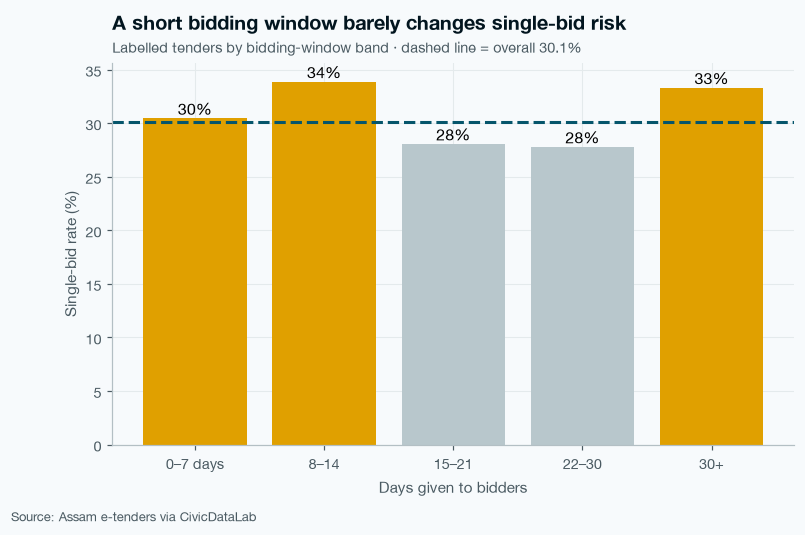

In [180]:
# Empty picture
fig, ax = plt.subplots(figsize=(8, 4.5))

# One upright bar per band
bars = ax.bar(win.index.astype(str), win["pct"], color=colors)

# % on top of each bar
ax.bar_label(bars, fmt="%.0f%%")

# Dashed line at the overall rate
ax.axhline(30.1, color=ts.THIRD, linestyle="--")

# Axis names
ax.set_xlabel("Days given to bidders")
ax.set_ylabel("Single-bid rate (%)")

# Title states the finding
ts.title(ax, "A short bidding window barely changes single-bid risk",
         "Labelled tenders by bidding-window band · dashed line = overall 30.1%")

# Source and save
ts.source(fig)
ts.save_fig(fig, "../reports/figures/S3c_single_bid_by_window.png")

### Insight · Single-bid rate by bidding window
- I expected short bidding windows to lead to more single bids, but the difference was small.
- Under 2 weeks was about 31 to 34%, 2 to 4 weeks about 28%, and over a month about 33%.
- Long windows going up again probably means big, complex jobs where few firms can bid anyway.
- Most labelled tenders give around 18 days, close to the usual three-week guideline.
- On its own the bidding window is a weak signal. I will still keep it for the model, because it may matter together with department or tender size.

## Step 6 · Single-bid rate for re-tenders

In [181]:
# How many labelled tenders are re-tenders (True) vs first-time (False)?
lab["is_retender"].value_counts()

is_retender
False    6165
True      625
Name: count, dtype: int64

In [182]:
# Single-bid rate: re-tenders vs first-time tenders
lab.groupby("is_retender")["single_bid"].agg(["count", "mean"])

,count,mean
is_retender,,
False,6165,0.297648
True,625,0.334400


In [183]:
# Same check, but only for tenders whose TITLE says re-tender
lab.groupby("title_says_retender")["single_bid"].agg(["count", "mean"])

,count,mean
title_says_retender,,
False,6738,0.300237
True,52,0.403846


In [184]:
# Same check for "same department + same title posted earlier"
lab.groupby("seen_before")["single_bid"].agg(["count", "mean"])

,count,mean
seen_before,,
False,6211,0.298181
True,579,0.331606


In [185]:
# Single-bid rate for each group (keep the rows where the column is True/False, then average)
first    = lab[lab["is_retender"] == False]["single_bid"].mean()
any_rt   = lab[lab["is_retender"] == True]["single_bid"].mean()
seen     = lab[lab["seen_before"] == True]["single_bid"].mean()
title_rt = lab[lab["title_says_retender"] == True]["single_bid"].mean()

In [186]:
# Put the four numbers into one small list with names, and turn them into %
rt = pd.Series({
    "First-time\n(6,165)": first,
    "Any re-tender\n(625)": any_rt,
    "Same title seen before\n(579)": seen,
    "Title says re-tender\n(52)": title_rt,
}) * 100
rt

First-time\n(6,165)              29.764801
Any re-tender\n(625)             33.440000
Same title seen before\n(579)    33.160622
Title says re-tender\n(52)       40.384615
dtype: float64

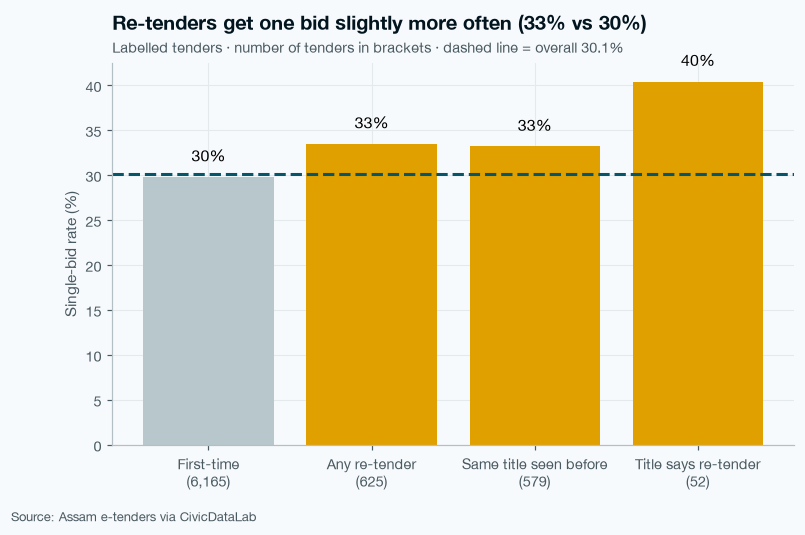

In [187]:
# Grey for first-time (our comparison), amber for the three re-tender groups
colors = [ts.NEUTRAL, ts.SINGLE, ts.SINGLE, ts.SINGLE]

# Empty picture
fig, ax = plt.subplots(figsize=(8, 4.5))

# One bar per group
bars = ax.bar(rt.index, rt, color=colors)

# % on top of each bar (padding=8 lifts the label a little higher, clear of the dashed line)
ax.bar_label(bars, fmt="%.0f%%", padding=8)

# Dashed line at the overall rate
ax.axhline(30.1, color=ts.THIRD, linestyle="--")
ax.set_ylabel("Single-bid rate (%)")

# Title states the finding
ts.title(ax, "Re-tenders get one bid slightly more often (33% vs 30%)",
         "Labelled tenders · number of tenders in brackets · dashed line = overall 30.1%")

# Source and save
ts.source(fig)
ts.save_fig(fig, "../reports/figures/S3d_single_bid_retender.png")


### Insight · Re-tenders
- Re-tenders had a slightly higher single-bid rate than first-time tenders: 33% vs 30%.
- Titles that clearly say re-tender reached 40%, but there were only 52 of them, so I don't trust that number much.
- Re-tenders are less than 1 in 10 labelled tenders, so this signal helps only a small group.
- These flags use only the title and earlier tenders, so they are safe to use in the model.
- Step 8 shows that how soon a tender is posted again matters even more.

## Step 7 · Single-bid rate by tender value

In [188]:
# Single-bid rate when the value is missing (True) vs given (False)
lab.groupby("value_missing")["single_bid"].agg(["count", "mean"])

,count,mean
value_missing,,
False,5773,0.313009
True,1017,0.233038


In [189]:
# The middle (median) tender value in ₹, for labelled tenders that have a value
lab["estimated_value"].median()

9523830.0

In [190]:
# Band edges in ₹: 0 → 10 lakh → 1 crore → 10 crore → no limit
edges = [0, 10_00_000, 1_00_00_000, 10_00_00_000, float("inf")]

# A name for each band (4 bands, so 4 names)
names = ["Under ₹10 lakh", "₹10 lakh–1 cr", "₹1–10 cr", "Over ₹10 cr"]

In [191]:
# Put each tender into its value band (missing values stay empty)
value_band = pd.cut(lab["estimated_value"], bins=edges, labels=names)

In [192]:
# For each value band: how many tenders, and the single-bid rate
lab.groupby(value_band)["single_bid"].agg(["count", "mean"])

,count,mean
estimated_value,,
Under ₹10 lakh,246,0.382114
₹10 lakh–1 cr,2740,0.320073
₹1–10 cr,2296,0.293554
Over ₹10 cr,491,0.329939


In [193]:
# Share of tenders with a missing value, in each year (year was made in Step 3)
lab.groupby(year)["value_missing"].mean()

published_date
2019    0.000000
2020    0.458333
2021    0.311258
2022    0.135669
2023    0.160261
Name: value_missing, dtype: float64

In [194]:
# Single-bid rate (%) for each value band
vb = lab.groupby(value_band)["single_bid"].mean() * 100

# Turn band names into plain text so we can add one more bar
vb.index = vb.index.astype(str)

# Add a fifth bar: tenders whose value is missing
vb["Value missing"] = lab[lab["value_missing"] == True]["single_bid"].mean() * 100
vb

estimated_value
Under ₹10 lakh    38.211382
₹10 lakh–1 cr     32.007299
₹1–10 cr          29.355401
Over ₹10 cr       32.993890
Value missing     23.303835
Name: single_bid, dtype: float64

In [195]:
# Amber if above the overall 30.1%, grey if below
colors = [ts.SINGLE if p > 30.1 else ts.NEUTRAL for p in vb]

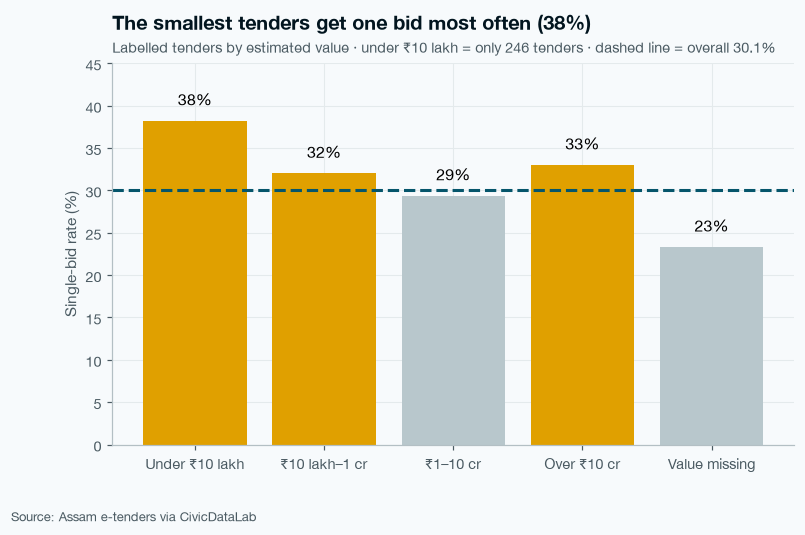

In [196]:
# Empty picture
fig, ax = plt.subplots(figsize=(8, 4.5))

# One bar per band, % on top
bars = ax.bar(vb.index, vb, color=colors)
ax.bar_label(bars, fmt="%.0f%%", padding=8)

# Make the y-axis go up to 45, so the tallest label has room below the subtitle
ax.set_ylim(0, 45)

# Dashed line at the overall rate
ax.axhline(30.1, color=ts.THIRD, linestyle="--")
ax.set_ylabel("Single-bid rate (%)")

# Title states the finding
ts.title(ax, "The smallest tenders get one bid most often (38%)",
         "Labelled tenders by estimated value · under ₹10 lakh = only 246 tenders · dashed line = overall 30.1%")

# Source and save
ts.source(fig)
ts.save_fig(fig, "../reports/figures/S3e_single_bid_by_value.png")

In [197]:
# Which departments post the most missing-value tenders? (top 5)
lab[lab["value_missing"] == True]["dept_main"].value_counts().head()

dept_main
Industries and Commerce Department              143
Home B                                          124
Health and Family Welfare Department            106
Assam Power Distribution Company Ltd             94
Welfare of Plain Tribes and Backward Classes     66
Name: count, dtype: int64

### Insight · Single-bid rate by tender value
- The middle labelled tender is worth about ₹95 lakh.
- Small tenders under ₹10 lakh had the highest rate (38%), probably because small jobs are not worth the effort for most companies. Only 246 tenders, though.
- Tenders between ₹1 and 10 crore had the lowest rate (29%), and tenders above ₹10 crore went up again to 33% because few firms are big enough.
- Tenders with no value had only 23%. I checked whether the year explained this, and it did not.
- Most no-value tenders come from supply departments like Health, Home and Industries, which already have low rates. So the missing value itself is not the reason.
- For S4 I will keep tender value (on a log scale) and value_missing, remembering they overlap with department.

## Step 8 · Repeat tenders — re-tender or yearly order?

In [198]:
# Days since the same department last posted the same title (empty if never before)
df["days_since_same"] = df.groupby(["dept_main", "title_key"])["published_date"].diff().dt.days

In [199]:
# How many tenders have a gap? (should match seen_before = 5,786)
df["days_since_same"].notna().sum()

5786

In [200]:
# Gap bands: within 2 months, 2–10 months, about a year (10–14 months), longer
edges = [-1, 60, 300, 430, 100000]
names = ["Within 2 months", "2–10 months", "About 1 year", "Over 14 months"]
gap_band = pd.cut(df["days_since_same"], bins=edges, labels=names)

In [201]:
# How many repeat tenders fall in each gap band?
gap_band.value_counts()

days_since_same
Within 2 months    4554
2–10 months         967
Over 14 months      168
About 1 year         97
Name: count, dtype: int64

In [202]:
# Rebuild the labelled table so it includes the new column, then single-bid rate by gap band
lab = df[df["single_bid"].notna()]
lab.groupby(gap_band)["single_bid"].agg(["count", "mean"])

,count,mean
days_since_same,,
Within 2 months,373,0.372654
2–10 months,155,0.245161
About 1 year,15,0.200000
Over 14 months,36,0.333333


In [203]:
# How many repeats came on the SAME day (gap = 0)? These are probably lots, not re-tenders
(df["days_since_same"] == 0).sum()

1734

In [204]:
# Single-bid rate (%) for each gap band
gb = lab.groupby(gap_band)["single_bid"].mean() * 100

# Turn band names into plain text so we can add one more bar
gb.index = gb.index.astype(str)

# Add a bar for first-time tenders (no earlier twin → gap is empty)
gb["First-time"] = lab[lab["days_since_same"].isna()]["single_bid"].mean() * 100
gb

days_since_same
Within 2 months    37.265416
2–10 months        24.516129
About 1 year       20.000000
Over 14 months     33.333333
First-time         29.818065
Name: single_bid, dtype: float64

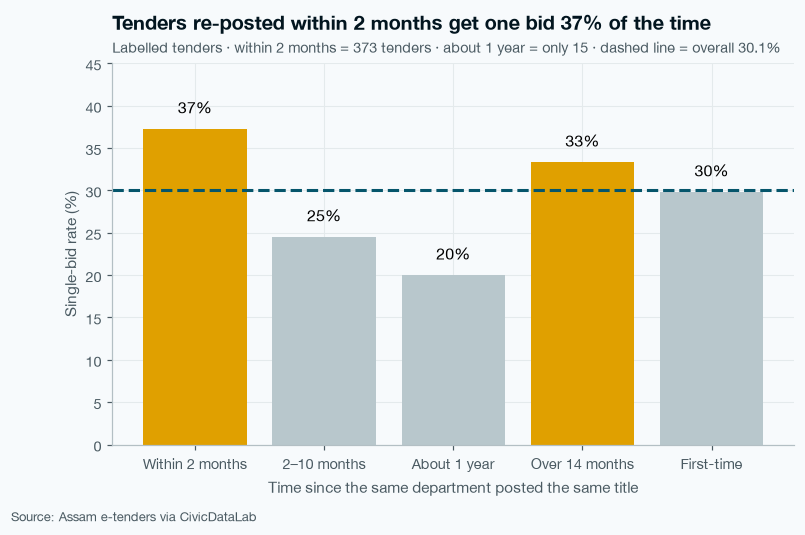

In [205]:
# Amber if above the overall 30.1%, grey if below
colors = [ts.SINGLE if p > 30.1 else ts.NEUTRAL for p in gb]

# Empty picture with room at the top
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(gb.index, gb, color=colors)
ax.bar_label(bars, fmt="%.0f%%", padding=8)
ax.set_ylim(0, 45)

# Dashed line at the overall rate
ax.axhline(30.1, color=ts.THIRD, linestyle="--")
ax.set_xlabel("Time since the same department posted the same title")
ax.set_ylabel("Single-bid rate (%)")

# Title states the finding
ts.title(ax, "Tenders re-posted within 2 months get one bid 37% of the time",
         "Labelled tenders · within 2 months = 373 tenders · about 1 year = only 15 · dashed line = overall 30.1%")

# Source and save
ts.source(fig)
ts.save_fig(fig, "../reports/figures/S3f_single_bid_by_repeat_gap.png")

In [206]:
# Same-day twins (gap = 0) → probably lots posted together
same_day = lab[lab["days_since_same"] == 0]["single_bid"]

# Re-posted 1 to 60 days later → probably true re-tenders
quick = lab[lab["days_since_same"].between(1, 60)]["single_bid"]

# Show how many, and the single-bid rate, for each
print("Same day :", len(same_day), round(same_day.mean() * 100, 1))
print("1–60 days:", len(quick), round(quick.mean() * 100, 1))

Same day : 148 33.1
1–60 days: 225 40.0


### Insight · Repeat tenders: re-tender or yearly order?
- Most repeat tenders came back within 2 months (4,554 of 5,786). Only 97 came back about a year later, so they are not yearly orders.
- 1,734 repeats were posted on the same day as the original. These look like one job split into lots, not failed tenders.
- After separating them, tenders re-posted 1 to 60 days later had a 40% single-bid rate. This was the strongest signal I found.
- Same-day lots were 33%, first-time tenders 30%, and tenders re-posted 2 to 10 months later only 25%.
- How soon a tender comes back matters more than whether it comes back.
- The S2 columns seen_before and is_retender include the 1,734 same-day lots. In S4 I will build cleaner features: days_since_same, retender_60d (gap 1 to 60) and same_day_lot (gap 0).

## Step 9 · The December 2022 spike


In [207]:
# Make a "year-month" column, e.g. 2022-12, from the publish date
df["pub_month"] = df["published_date"].dt.to_period("M")

In [208]:
# Count tenders per month and show the last 12 months of data
monthly = df["pub_month"].value_counts().sort_index()
monthly.tail(12)

pub_month
2022-06     462
2022-07     433
2022-08     393
2022-09     508
2022-10     541
2022-11     855
2022-12    1794
2023-01     908
2023-02     664
2023-03     715
2023-04     281
2023-05       2
Freq: M, Name: count, dtype: int64

In [209]:
# Which departments posted the most tenders in December 2022? (top 5)
df[df["pub_month"] == "2022-12"]["dept_main"].value_counts().head()

dept_main
Public Works Roads Department              631
National Health Mission                    551
Public Works Building and NH Department    110
Department of Water Resources               94
Bodoland Territorial Council                86
Name: count, dtype: int64

In [210]:
# Rebuild labelled table (to include pub_month), then count + single-bid rate for the last 12 months
lab = df[df["single_bid"].notna()]
lab.groupby("pub_month")["single_bid"].agg(["count", "mean"]).tail(12)

,count,mean
pub_month,,
2022-06,361,0.396122
2022-07,315,0.371429
2022-08,306,0.300654
2022-09,426,0.338028
2022-10,419,0.348449
2022-11,733,0.380628
2022-12,1264,0.193038
2023-01,610,0.268852
2023-02,485,0.228866


In [211]:
# December 2022 single-bid rate WITHOUT National Health Mission
dec = lab[lab["pub_month"] == "2022-12"]
dec[dec["dept_main"] != "National Health Mission"]["single_bid"].mean()

0.22041984732824427

In [212]:
# Last 12 months of tender counts
last12 = monthly.tail(12)

# Deep teal for December 2022, grey for every other month
colors = [ts.THIRD if str(m) == "2022-12" else ts.NEUTRAL for m in last12.index]

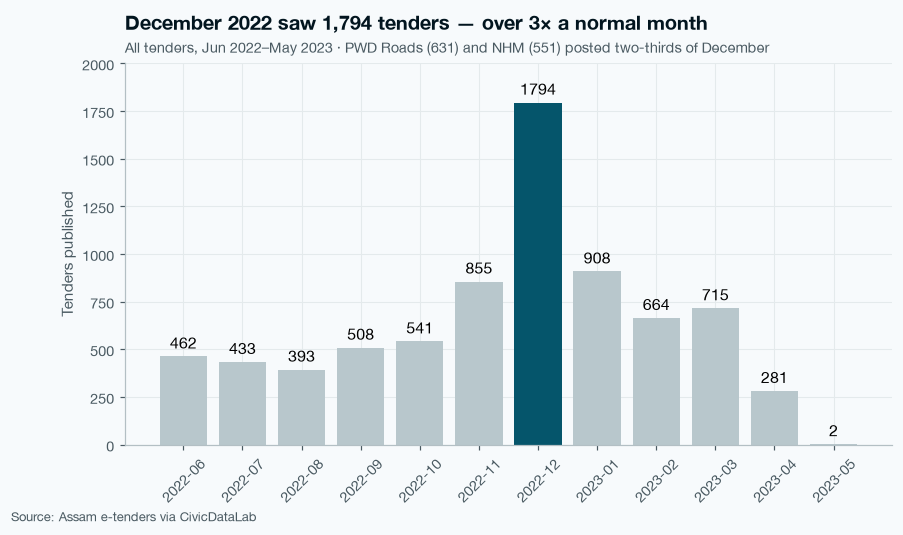

In [213]:
# Empty picture, a bit wider for 12 months
fig, ax = plt.subplots(figsize=(9, 4.5))

# One bar per month, with the count on top
bars = ax.bar(last12.index.astype(str), last12, color=colors)
ax.bar_label(bars, padding=3)
ax.set_ylim(0, 2000)

# Tilt the month labels so they don't overlap
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Tenders published")

# Title states the finding
ts.title(ax, "December 2022 saw 1,794 tenders — over 3× a normal month",
         "All tenders, Jun 2022–May 2023 · PWD Roads (631) and NHM (551) posted two-thirds of December")

# Source and save
ts.source(fig)
ts.save_fig(fig, "../reports/figures/S3g_dec2022_spike.png")

### Insight · The December 2022 spike
- December 2022 had 1,794 tenders, about three times a normal month. This is likely the year-end rush to spend budget before 31 March.
- PWD Roads (631) and NHM (551) posted about two-thirds of them.
- Only 19% of December tenders got a single bid, much lower than the usual 30 to 40%. Without NHM it was 22%, so most departments saw more competition that month.
- December is about half of the validation data (1,264 of 2,416 tenders), so one unusual month could make the model look better or worse than it is.
- In S5 I will report validation results for Oct to Nov and December separately. In S4 I will add a feature for months left until the financial year ends.

## Step 10 · The same questions in SQL

In [214]:
# open (create) the database file

# sqlite3 = a tiny database built into Python (nothing to install)
import sqlite3

# Open (or create) a database FILE so it can be saved and shared
con = sqlite3.connect("../data/processed/tenderlens.db")

In [215]:
# Only the columns we need (SQLite can't store the special month column pub_month)
cols = ["dept_main", "published_date", "single_bid", "bid_window_days",
        "is_retender", "days_since_same", "value_missing", "estimated_value"]

# Copy those columns into a database table called "tenders" (replace it if it already exists)
df[cols].to_sql("tenders", con, index=False, if_exists="replace")

39411

In [216]:
# SQL question 1: how many labelled tenders, and what % got a single bid?
q1 = """
SELECT COUNT(single_bid)               AS labelled,
       ROUND(AVG(single_bid) * 100, 1) AS single_bid_pct
FROM tenders
"""
pd.read_sql(q1, con)

,labelled,single_bid_pct
0,6790,30.1


In [217]:
# SQL question 2: single-bid rate per department, only departments with 50+ labelled tenders
q2 = """
SELECT dept_main,
       COUNT(single_bid)               AS labelled,
       ROUND(AVG(single_bid) * 100, 1) AS single_bid_pct
FROM tenders
WHERE single_bid IS NOT NULL
GROUP BY dept_main
HAVING COUNT(single_bid) >= 50
ORDER BY single_bid_pct DESC
"""
pd.read_sql(q2, con)

,dept_main,labelled,single_bid_pct
0,Food Civil Supplies and Consumer Affairs Depar...,129,51.2
1,Public Works Roads Department-Externally Aided...,176,40.9
2,Department of Housing and Urban Affairs,90,38.9
3,Irrigation Department,115,38.3
4,Directorate of Agriculture and Assam Seed Corp...,206,37.9
5,Bodoland Territorial Council,799,37.0
6,Principal Secretary- P and RD- Assam Secretariat,69,36.2
7,Welfare of Plain Tribes and Backward Classes,179,34.6
8,Public Works Building and NH Department,876,32.6
9,Department of Water Resources,262,31.7


In [218]:
# SQL question 3: single-bid rate per publish year
q3 = """
SELECT strftime('%Y', published_date)  AS year,
       COUNT(single_bid)               AS labelled,
       ROUND(AVG(single_bid) * 100, 1) AS single_bid_pct
FROM tenders
WHERE single_bid IS NOT NULL
GROUP BY year
ORDER BY year
"""
pd.read_sql(q3, con)

,year,labelled,single_bid_pct
0,2019,20,60.0
1,2020,24,41.7
2,2021,302,41.4
3,2022,4909,31.6
4,2023,1535,22.5


In [219]:
# SQL question 4: put each tender into a repeat group, then single-bid rate per group
q4 = """
SELECT CASE
         WHEN days_since_same IS NULL THEN '1 First-time'
         WHEN days_since_same = 0     THEN '2 Same-day lot'
         WHEN days_since_same <= 60   THEN '3 Re-posted 1-60 days'
         WHEN days_since_same <= 300  THEN '4 Re-posted 2-10 months'
         ELSE                              '5 Re-posted after 10 months'
       END                              AS repeat_type,
       COUNT(single_bid)               AS labelled,
       ROUND(AVG(single_bid) * 100, 1) AS single_bid_pct
FROM tenders
WHERE single_bid IS NOT NULL
GROUP BY repeat_type
ORDER BY repeat_type
"""
pd.read_sql(q4, con)

,repeat_type,labelled,single_bid_pct
0,1 First-time,6211,29.8
1,2 Same-day lot,148,33.1
2,3 Re-posted 1-60 days,225,40.0
3,4 Re-posted 2-10 months,155,24.5
4,5 Re-posted after 10 months,51,29.4


### Insight · The same questions in SQL
- I repeated four questions in SQL using a SQLite database saved as data/processed/tenderlens.db (39,411 tenders, 8 columns).
- All four answers matched pandas exactly: 30.1% overall, 51.2% to 15.4% by department, 41% to 22% by year, and 40% for tenders re-posted within 1 to 60 days.
- Two different tools giving the same answer means the findings are not a coding mistake.
- SQL used: WHERE vs HAVING, GROUP BY with COUNT and AVG, CASE WHEN, and strftime.

## Step 11 · Save our work

In [220]:
# os = tools for working with folders and files
import os

# Make the "sql" folder inside TenderLens (does nothing if it already exists)
os.makedirs("../sql", exist_ok=True)

# Join the 4 queries into one text, with ";" at the end of each (SQL's full stop)
all_sql = q1 + ";\n" + q2 + ";\n" + q3 + ";\n" + q4 + ";\n"

# Write that text into a new file: sql/eda_queries.sql
with open("../sql/eda_queries.sql", "w") as f:
    f.write(all_sql)

In [221]:
# Run the department query again and save the answer as a CSV in reports/
pd.read_sql(q2, con).to_csv("../reports/s3_single_bid_by_department.csv", index=False)

In [222]:
# Hang up the "phone line" to the database (the .db file stays saved)
con.close()

## S3 Summary - EDA & SQL

### Starting point
- 6,790 tenders have a known bid count. The rest are older files with no bidder list, so I left them out.
- 2,044 of these got only one bid, which is 30.1%. I use this as the normal level to compare against.
- One bid means no competition, so the government has no other price to compare with.

### Over time
- The single-bid rate went down: 41% in 2021, 32% in 2022 and 22% in early 2023.
- 2019 and 2020 have only about 20 tenders each, so I did not rely on them.
- This matters because the model will learn from older data where single bids were more common.

### Department
- This was one of the clearest patterns.
- Food & Civil Supplies had the highest rate at 51%, and PWD Roads (externally aided) had 41%.
- The two health departments had the lowest, at 15% and 18%.

### Bidding window
- I expected short windows to lead to more single bids, but the difference was small.
- Under 2 weeks was about 33%, 2 to 4 weeks about 28%, and over a month about 33%.
- Most tenders gave around 18 days.

### Re-tenders
- Re-tenders had a slightly higher rate than new tenders (33% vs 30%).
- Titles that say "re-tender" reached 40%, but there were only 52 of them.

### Tender value
- Small tenders under 10 lakh had the highest rate (38%).
- Tenders between 1 and 10 crore had the lowest (29%), and tenders above 10 crore went up again to 33%.
- Tenders with no value had only 23%. Most of them came from supply departments like Health and Industries, which already have low rates, so the missing value itself is not the reason.

### Repeat tenders
- Most repeats were posted again within 2 months, not after a year, so they are not yearly orders.
- 1,734 repeats were posted on the same day as the original. These look like one job split into lots.
- After separating them, tenders re-posted 1 to 60 days later had a 40% single-bid rate. This was the strongest signal I found.
- Tenders re-posted 2 to 10 months later had only 25%.

### December 2022
- December 2022 had 1,794 tenders, about three times a normal month, likely because departments rush to spend budget before March.
- PWD Roads and NHM posted about two-thirds of them.
- Only 19% of December tenders got a single bid (22% without NHM).
- December is about half of the validation data, so I will check model results for it separately.

### SQL check
- I repeated four of the questions in SQL using SQLite.
- All results matched the pandas results.

### Files saved
- Charts S3a to S3g in reports/figures
- SQL queries in sql/eda_queries.sql
- Department table in reports/s3_single_bid_by_department.csv
- Database in data/processed/tenderlens.db

### Next steps (S4)
- Create features for re-posted within 60 days, same-day lot and days since the same title.
- Keep department, value (log scale), value missing and bidding window.
- Add months left until the financial year ends.